In [ ]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as f
from pyspark.sql.functions import col
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Create a spark session (which will run spark jobs)
spark = (
    SparkSession.builder.appName("Project 1")
    .config("spark.sql.repl.eagerEval.enabled", True) 
    .config("spark.sql.parquet.cacheMetadata", "true")
    .config("spark.sql.session.timeZone", "Etc/UTC")
    .getOrCreate()
)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/10/08 11:07:52 WARN Utils: Your hostname, Lachys-Laptop, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
25/10/08 11:07:52 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/08 11:07:54 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [ ]:
result_df=spark.read.csv("../data/curated/merged_postcode_income.csv", header=True)

In [3]:
agg_data=spark.read.parquet('../data/curated/agg_by_userbiz/')
agg_data

user_id,merchant_abn,count,mean,merch_fraud_prob,con_fraud_prob,state,postcode
15373,12543580354,2,220.80766866720526,NULL,NULL,NSW,2153
15373,11841065357,1,184.81218668910532,NULL,NULL,NSW,2153
15373,12870663624,1,148.8158448349653,NULL,NULL,NSW,2153
15373,14965232967,1,781.588036086858,NULL,12.319746480481419,NSW,2153
15373,13118172970,3,154.45814693690537,NULL,NULL,NSW,2153
15373,15069598461,2,71.96103421893008,NULL,NULL,NSW,2153
15373,15061716544,1,12.668487328776598,NULL,NULL,NSW,2153
15373,15269431008,2,128.8019391272781,NULL,NULL,NSW,2153
15373,19237425345,1,195.8666055562444,NULL,NULL,NSW,2153
15373,15560455575,1,52.7378918156653,NULL,NULL,NSW,2153


In [5]:
user_agg=agg_data.groupBy('user_id').agg(
    f.sum('count').alias('count'),
    f.avg('mean').alias('mean')
)
user_agg

user_id,count,mean
21342,571,168.85447963292762
13248,559,140.18522209265632
17979,550,186.99309465849217
21965,558,170.00949318139237
9945,538,186.46460170120002
19979,549,174.66218874420198
13518,538,212.66990298249922
22165,561,161.4183359862121
11276,546,156.92410005947193
11938,547,154.90050996421803


In [7]:
user_agg_pd=user_agg.toPandas()

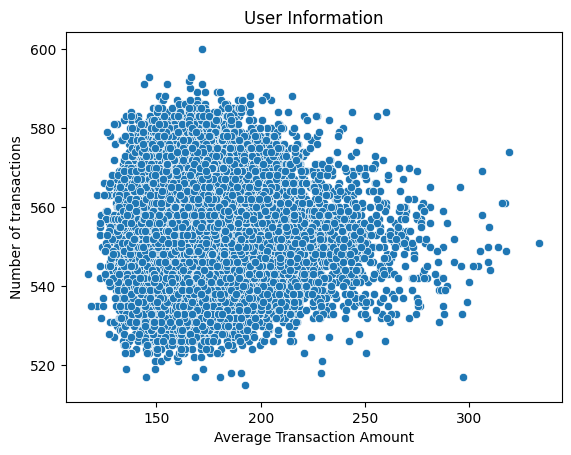

In [ ]:
sns.scatterplot(data=user_agg_pd, x='mean', y='count')
plt.xlabel('Average Transaction Amount')
plt.ylabel('Number of Transactions')
plt.title('User Information')
plt.show()

In [10]:
biz_agg=agg_data.groupBy('merchant_abn').agg(
    f.sum('count').alias('count'),
    f.avg('mean').alias('mean')
)
biz_agg

merchant_abn,count,mean
83412691377,14288,34.87049873624943
73256306726,5260,283.41027481980694
35344855546,1518,87.75188757487723
15613631617,1783,303.1120120913352
34440496342,215,90.35050618004642
73841664453,959,87.20663330574303
19839532017,726,157.0
60654402457,199,85.65342685212403
78916025936,51,209.44736625551403
38986645707,23,483.87252169646996


In [11]:
biz_agg_pd=biz_agg.toPandas()

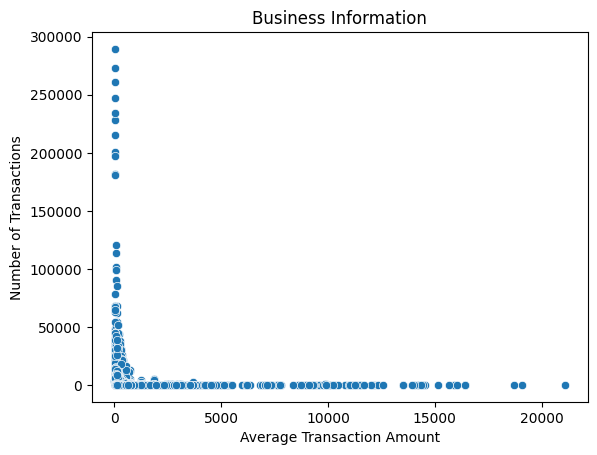

25/10/08 12:02:17 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 866319 ms exceeds timeout 120000 ms
25/10/08 12:02:17 WARN SparkContext: Killing executors is not supported by current scheduler.
25/10/08 12:02:20 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:342)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:132)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$

In [12]:
sns.scatterplot(data=biz_agg_pd, x='mean', y='count')
plt.xlabel('Average Transaction Amount')
plt.ylabel('Number of Transactions')
plt.title('Business Information')
plt.show()

In [ ]:
pdf = result_df.toPandas()
# Drop missing values (important to avoid errors)
pdf = pdf.dropna(subset=["median_total_income_2020"])

# Histogram
plt.figure(figsize=(8, 6))
plt.hist(pdf["median_total_income_2020"], bins=20, edgecolor="black", alpha=0.7)

plt.xlabel("Median Total Income (2020)")
plt.ylabel("Number of Postcodes")
plt.title("Distribution of Median Total Income by Postcode (2020)")
plt.tight_layout()
plt.show()

In [ ]:
# Drop missing values
pdf = pdf.dropna(subset=["median_total_income_2020"])

# Define bin edges in 10k intervals
min_val = pdf["median_total_income_2020"].min()
max_val = pdf["median_total_income_2020"].max()

# Start from the nearest 10k below min, go to nearest 10k above max
bins = np.arange((min_val // 10000) * 10000, ((max_val // 10000) + 1) * 10000 + 1, 10000)

# Create labels like "30k-40k", "40k-50k", etc.
labels = [f"{int(bins[i]/1000)}k-{int(bins[i+1]/1000)}k" for i in range(len(bins)-1)]

# Categorize incomes into bins
pdf["income_bin"] = pd.cut(pdf["median_total_income_2020"], bins=bins, labels=labels, right=False)

# Count how many postcodes fall into each bin
bin_counts = pdf["income_bin"].value_counts().sort_index()

# Bar chart
plt.figure(figsize=(10, 6))
bin_counts.plot(kind="bar", color="skyblue", edgecolor="black")

plt.xlabel("Income Bin")
plt.ylabel("Number of Postcodes")
plt.title("Postcodes Grouped into 10k Income Bins (2020)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
